In [5]:
import numpy as np 
import pandas as pd 

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, PowerTransformer, LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator

import data_clean_utils

In [6]:
!pip install mlflow dagshub 

In [7]:
import dagshub

dagshub.auth.add_app_token("1430185965d5cc1c10ff15d59e0405f69b16adca")

In [8]:
dagshub.init(
    repo_owner='anni0955',
    repo_name='delivery-time-prediction',
    mlflow=True
)

Accessing as anni0955

Initialized MLflow to track repo "anni0955/delivery-time-prediction"

Repository anni0955/delivery-time-prediction initialized!

In [9]:
from sklearn import set_config
set_config(transform_output='pandas')

## Load the data

In [10]:
df = pd.read_csv('train.csv')

## Clean data

In [11]:
data_clean_utils.perform_data_cleanining(df)

In [13]:
df = pd.read_csv('cleaned-data.csv')
df

,rider_id,rider_age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance,distance_type
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149,short
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,BANG,25,3,friday,0,5.0,19.0,evening,20.183530,very_long
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758,short
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401,medium
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,...,JAP,24,3,thursday,0,10.0,11.0,morning,1.489846,short
45498,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,windy,jam,...,AGR,16,2,wednesday,0,15.0,19.0,evening,NaN,NaN
45499,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,...,CHEN,11,3,friday,0,15.0,23.0,night,4.657195,short
45500,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,...,COIMB,7,3,monday,0,5.0,13.0,afternoon,6.232393,medium


In [17]:
df.columns

Index(['rider_id', 'rider_age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance', 'distance_type'],
      dtype='object')

In [19]:
cols_to_drop = [
    'rider_id',
    'restaurant_latitude',
    'restaurant_longitude', 
    'delivery_latitude', 
    'delivery_longitude',
    'order_date',
    'order_time_hour',
    'order_day',
    'city_name',
    'order_day_of_week',
    'order_month'
]

df.drop(columns=cols_to_drop, inplace=True)
df

,rider_age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,24,1,15.0,morning,3.025149,short
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,0,5.0,evening,20.183530,very_long
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,1,15.0,morning,1.552758,short
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,0,10.0,evening,7.790401,medium
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,30.0,4.8,windy,high,1,meal,motorcycle,0.0,no,metropolitian,32,0,10.0,morning,1.489846,short
45498,21.0,4.6,windy,jam,0,buffet,motorcycle,1.0,no,metropolitian,36,0,15.0,evening,NaN,NaN
45499,30.0,4.9,cloudy,low,1,drinks,scooter,0.0,no,metropolitian,16,0,15.0,night,4.657195,short
45500,20.0,4.7,cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,26,0,5.0,afternoon,6.232393,medium


In [20]:
df.isna().sum()

,0
rider_age,1854
ratings,1908
weather,525
traffic,510
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,993
festival,228
city_type,1198


In [21]:
df.duplicated().sum()

np.int64(0)

<Axes: >

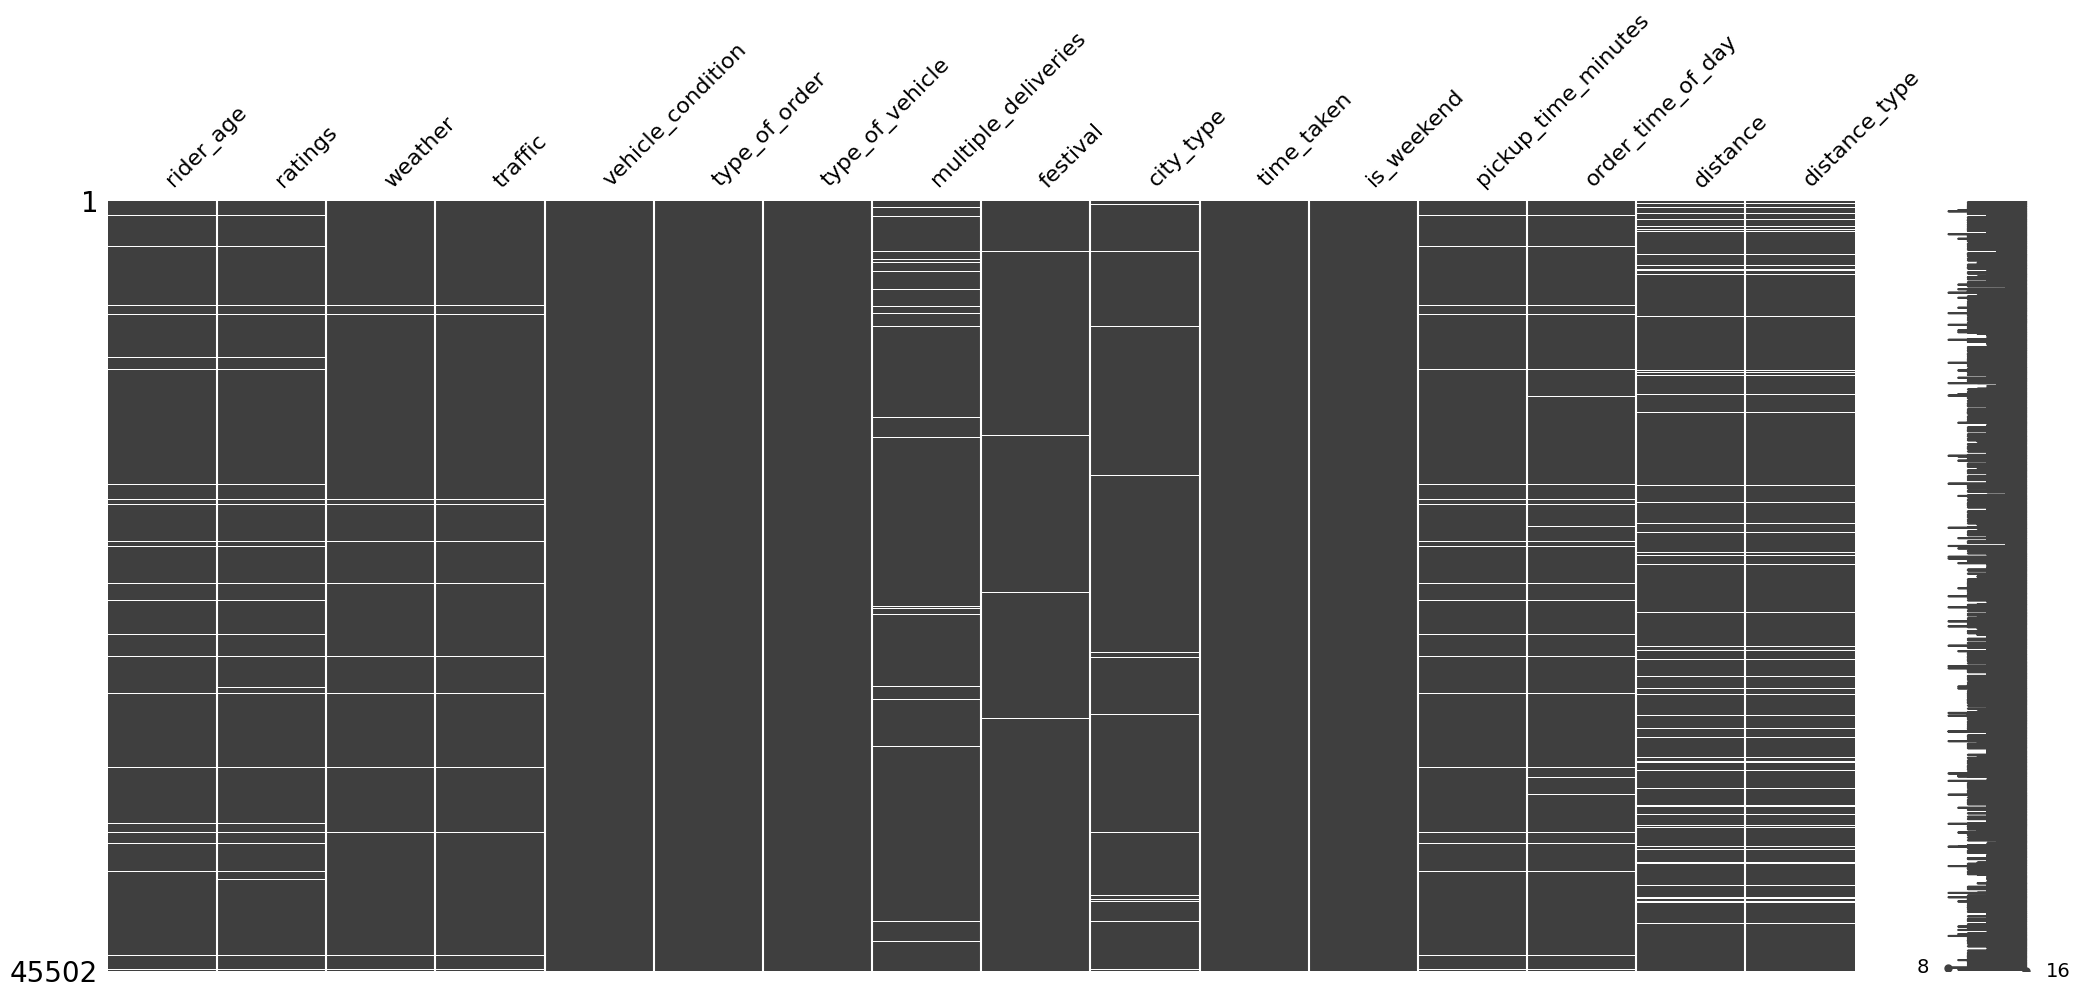

In [22]:
import missingno as msno
msno.matrix(df)

In [23]:
import mlflow

In [24]:
mlflow.set_tracking_uri('https://dagshub.com/anni0955/delivery-time-prediction.mlflow/')

In [25]:
mlflow.set_experiment('Exp 1: keep vs drop Missing Values')

2026/03/17 08:55:48 INFO mlflow.tracking.fluent: Experiment with name 'Exp 1: keep vs drop Missing Values' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/cb949b67d3e4430a9f14bf57ecb64ee6', creation_time=1773737748728, experiment_id='0', last_update_time=1773737748728, lifecycle_stage='active', name='Exp 1: keep vs drop Missing Values', tags={}, workspace='default'>

In [30]:
temp_df = df.copy().dropna()

In [31]:
x = temp_df.drop(columns=['time_taken'])
y = temp_df['time_taken']

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=42)

In [33]:
print('shape of x_train', x_train.shape)
print('shape of x_test', x_test.shape)

shape of x_train (30156, 15)
shape of x_test (7539, 15)


In [34]:
x_train.isna().sum()

,0
rider_age,0
ratings,0
weather,0
traffic,0
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,0
festival,0
city_type,0


In [35]:
x_train.columns

Index(['rider_age', 'ratings', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'is_weekend', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

In [36]:
len(x_train.columns)

15

In [41]:
num_cols = ['rider_age', 'ratings', 
            'pickup_time_minutes', 'distance']

nominal_cat_cols = ['weather', 'type_of_vehicle', 'festival',
                    'city_type',
                    'is_weekend',
                    'order_time_of_day', 'type_of_order']

ordinal_cat_cols = ['traffic', 'distance_type']

In [42]:
traffic_order = ['low', 'medium', 'high', 'jam']
distance_type_order = ['short', 'medium', 'long', 'very_long'] 

In [43]:
preprocessor = ColumnTransformer(transformers=[
    ('scale', MinMaxScaler(), num_cols),
    ('nominal_encode', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_cat_cols),
    ('ordinal_encode', OrdinalEncoder(categories=[traffic_order, distance_type_order]), ordinal_cat_cols)
], remainder='passthrough', n_jobs=-1, force_int_remainder_cols=False, verbose_feature_names_out=False)

preprocessor.set_output(transform='pandas')

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['rider_age', 'ratings', 'pickup_time_minutes',
                                  'distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['weather', 'type_of_vehicle', 'festival',
                                  'city_type', 'is_weekend',
                                  'order_time_of_day', 'type_of_order']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high', 'jam'],
                                                            ['short', 'medium',
                                                             'long',
                                                             'very_long']]),
                                 ['traffic', 'distance_type'])],
                  verbose_feature_names_out=False)

In [44]:
x_train_trans = preprocessor.fit_transform(x_train)
x_test_trans = preprocessor.transform(x_test)

x_train_trans

,rider_age,ratings,pickup_time_minutes,distance,weather_fog,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,type_of_vehicle_motorcycle,...,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,type_of_order_drinks,type_of_order_meal,type_of_order_snack,traffic,distance_type,vehicle_condition,multiple_deliveries
8708,0.473684,0.56,1.0,0.404165,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,3.0,1.0,0,2.0
25198,1.000000,0.76,0.0,0.154044,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0,1.0
34049,0.473684,0.80,0.5,0.002461,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,1,0.0
25987,1.000000,0.92,1.0,0.460411,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,0,1.0
37121,0.526316,0.76,0.5,0.243676,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20239,0.578947,0.92,0.5,0.451895,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,3.0,2.0,0,0.0
7590,0.052632,1.00,1.0,0.612270,0.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,1,1.0
13610,0.526316,0.92,0.0,0.322877,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1,0.0
1045,0.947368,0.96,0.5,0.004486,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1.0


In [45]:
pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [46]:
pt.lambdas_

array([0.32446096])

In [51]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()

rf.fit(x_train_trans, y_train_pt.values.ravel())

RandomForestRegressor()

In [52]:
y_pred_train = rf.predict(x_train_trans)
y_pred_test = rf.predict(x_test_trans)

In [55]:
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [56]:
from sklearn.metrics import r2_score, mean_absolute_error

print(f'MAE on train data is {mean_absolute_error(y_train, y_pred_train_org):.2f} minutes')
print(f'MAE on test data is {mean_absolute_error(y_test, y_pred_test_org):.2f} minutes')

print(f'r2_score on train data is {r2_score(y_train, y_pred_train_org):.2f}')
print(f'r2_score on test data is {r2_score(y_test, y_pred_test_org):.2f}')

MAE on train data is 1.15 minutes
MAE on test data is 3.09 minutes
r2_score on train data is 0.98
r2_score on test data is 0.83


In [57]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf, x_train_trans, y_train_pt.values.ravel(), cv=5, scoring='r2', n_jobs=-1)
scores

array([0.80841891, 0.81023664, 0.81037056, 0.80974955, 0.81154905])

In [58]:
scores.mean()

np.float64(0.8100649426471935)

<Axes: >

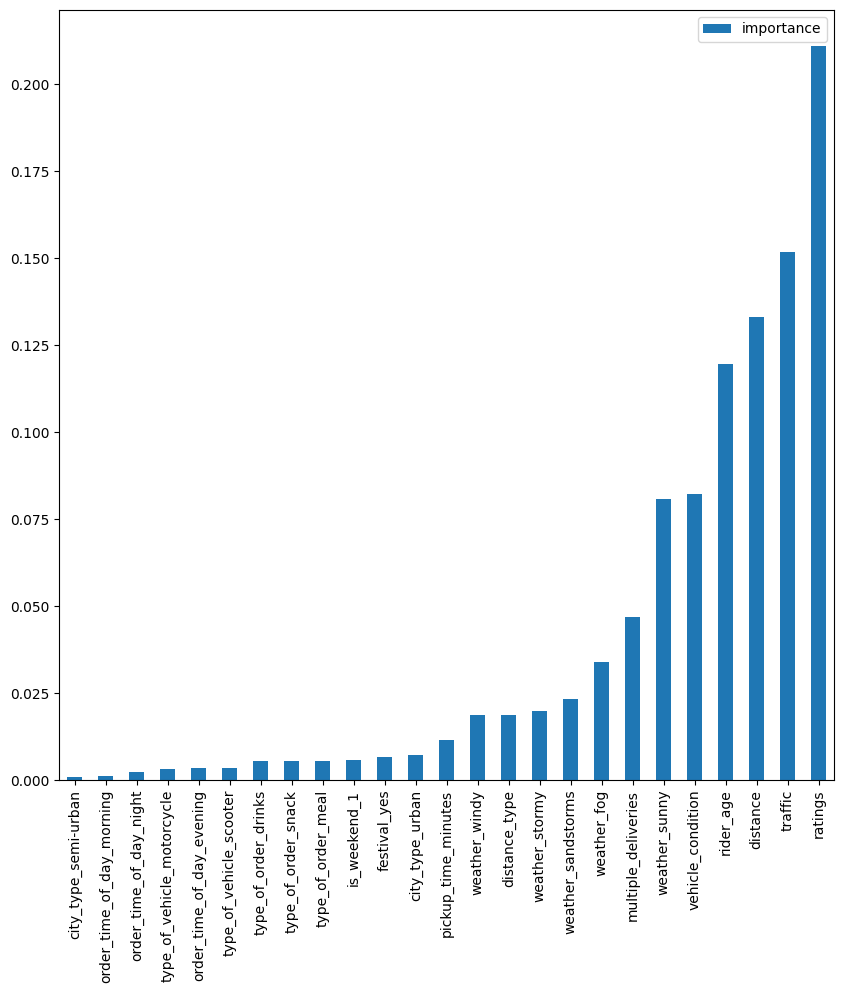

In [59]:
# feature importance plot 
(
    pd.DataFrame(rf.feature_importances_,
                index=x_train_trans.columns,
                columns=['importance'])
                .sort_values(by='importance')
                .plot(kind='bar', figsize=(10,10))
)

In [61]:
with mlflow.start_run(run_name='drop_missing_values'):
    mlflow.log_param('experiment_type', 'drop_missing_values')
    mlflow.log_params(rf.get_params())

    mlflow.log_metric('training_error:', mean_absolute_error(y_train, y_pred_train_org))
    mlflow.log_metric('testing_error:', mean_absolute_error(y_test, y_pred_test_org))
                      
    mlflow.log_metric('training_r2:', r2_score(y_train, y_pred_train_org))
    mlflow.log_metric('testign_r2:', r2_score(y_test, y_pred_test_org))
                      
    mlflow.log_metric('cross_val_score', scores.mean())

🏃 View run drop_missing_values at: https://dagshub.com/anni0955/delivery-time-prediction.mlflow/#/experiments/0/runs/2722a82786e148b784abc4f192508b81
🧪 View experiment at: https://dagshub.com/anni0955/delivery-time-prediction.mlflow/#/experiments/0


In [64]:
from sklearn.feature_selection import RFECV

rfecv = RFECV(
    estimator=rf,
    step=10,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

In [65]:
rfecv.fit(x_train_trans, y_train_pt.values.ravel())

RFECV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1, scoring='r2', step=10,
      verbose=2)

In [66]:
rfecv.get_feature_names_out()

array(['rider_age', 'ratings', 'pickup_time_minutes', 'distance',
       'weather_fog', 'weather_sandstorms', 'weather_stormy',
       'weather_sunny', 'weather_windy', 'type_of_vehicle_motorcycle',
       'type_of_vehicle_scooter', 'festival_yes', 'city_type_semi-urban',
       'city_type_urban', 'is_weekend_1', 'order_time_of_day_evening',
       'order_time_of_day_morning', 'order_time_of_day_night',
       'type_of_order_drinks', 'type_of_order_meal',
       'type_of_order_snack', 'traffic', 'distance_type',
       'vehicle_condition', 'multiple_deliveries'], dtype=object)

In [67]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()

rf.fit(rfecv.transform(x_train_trans), y_train_pt.values.ravel())

RandomForestRegressor()

In [68]:
y_pred_train = rf.predict(rfecv.transform(x_train_trans))
y_pred_test = rf.predict(rfecv.transform(x_test_trans))

In [69]:
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1, 1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1, 1))

In [70]:
print(f'MAE on train data is {mean_absolute_error(y_train, y_pred_train_org):.2f} minutes')
print(f'MAE on test data is {mean_absolute_error(y_test, y_pred_test_org):.2f} minutes')

print(f'r2_score on train data is {r2_score(y_train, y_pred_train_org):.2f}')
print(f'r2_score on test data is {r2_score(y_test, y_pred_test_org):.2f}')

MAE on train data is 1.15 minutes
MAE on test data is 3.09 minutes
r2_score on train data is 0.98
r2_score on test data is 0.83


In [71]:
scores = cross_val_score(rf, x_train_trans, y_train_pt.values.ravel(), cv=5, scoring='r2', n_jobs=-1)
scores

array([0.80765257, 0.81065419, 0.81052493, 0.81074109, 0.81213951])

In [72]:
scores.mean()

np.float64(0.810342458125262)

In [73]:
rf.feature_importances_

array([0.11884225, 0.21220438, 0.0114425 , 0.13276831, 0.03313174,
       0.02313087, 0.01930491, 0.07908827, 0.01789377, 0.00309824,
       0.00342652, 0.00642953, 0.0007901 , 0.00721132, 0.00578895,
       0.00328892, 0.0011866 , 0.00224386, 0.00534349, 0.00558494,
       0.00537669, 0.15207408, 0.01892886, 0.08128172, 0.05013919])

<Axes: >

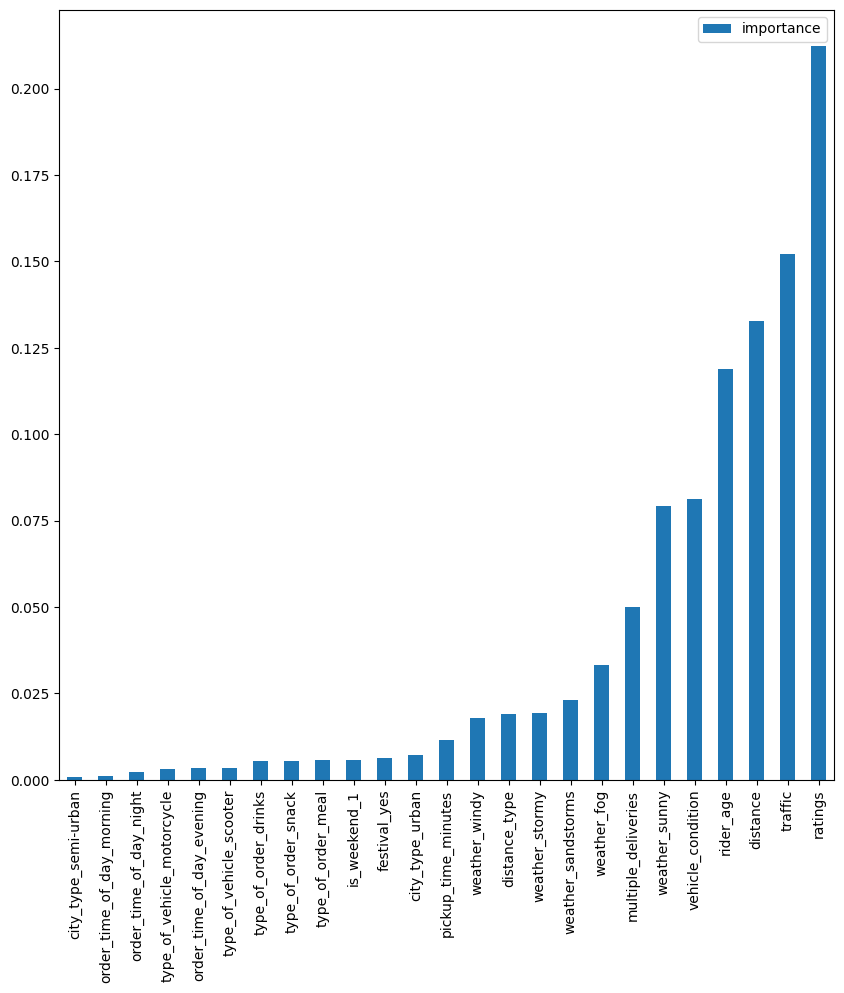

In [74]:
(
    pd.DataFrame(rf.feature_importances_,
                index=x_train_trans.columns,
                columns=['importance'])
                .sort_values(by='importance')
                .plot(kind='bar', figsize=(10,10))
)

## Impute missing values 

In [75]:
temp_df = df.copy()

x = temp_df.drop(columns=['time_taken'])
y = temp_df['time_taken']

In [80]:
missing_cols = (
    df
    .isna()
    .any(axis=0)
    .loc[lambda x: x]
    .index
)

missing_cols

Index(['rider_age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

In [81]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=42)

In [82]:
x_train.isna().sum()

,0
rider_age,1470
ratings,1510
weather,421
traffic,407
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,795
festival,188
city_type,968


In [83]:
pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [84]:
missing_cols

Index(['rider_age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

In [85]:
(
    x_train
    .isna()
    .any(axis=1)
    .mean()
    .round(2) * 100
)

np.float64(17.0)

## Imputation pipeline 

In [86]:
x_train.isna().sum()

,0
rider_age,1470
ratings,1510
weather,421
traffic,407
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,795
festival,188
city_type,968


In [87]:
features_to_fill_mode = ['city_type', 'multiple_deliveries', 'festival']
features_to_fill_missing = [col for col in nominal_cat_cols if col not in features_to_fill_mode]

features_to_fill_missing

['weather',
 'type_of_vehicle',
 'is_weekend',
 'order_time_of_day',
 'type_of_order']

In [88]:
simple_imputer = ColumnTransformer(transformers=[
    ('mode_imputer', SimpleImputer(strategy='most_frequent'), features_to_fill_mode),
    # ye isliye kiya kyuki OHE missing rows pr kam ni krta hai to hmne wha missing dal diya 
    ('missing_imputer', SimpleImputer(strategy='constant', fill_value='missing'), features_to_fill_missing)
], remainder='passthrough', n_jobs=-1, force_int_remainder_cols=False, verbose_feature_names_out=False)

simple_imputer

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('mode_imputer',
                                 SimpleImputer(strategy='most_frequent'),
                                 ['city_type', 'multiple_deliveries',
                                  'festival']),
                                ('missing_imputer',
                                 SimpleImputer(fill_value='missing',
                                               strategy='constant'),
                                 ['weather', 'type_of_vehicle', 'is_weekend',
                                  'order_time_of_day', 'type_of_order'])],
                  verbose_feature_names_out=False)

In [89]:
simple_imputer.fit_transform(x_train)

,city_type,multiple_deliveries,festival,weather,type_of_vehicle,is_weekend,order_time_of_day,type_of_order,rider_age,ratings,traffic,vehicle_condition,pickup_time_minutes,distance,distance_type
11029,metropolitian,1.0,no,windy,electric_scooter,0,evening,snack,26.0,4.7,jam,2,10.0,9.177684,medium
15665,metropolitian,1.0,no,windy,motorcycle,0,afternoon,drinks,21.0,4.9,medium,2,5.0,6.081536,medium
14475,metropolitian,1.0,no,stormy,scooter,1,missing,meal,NaN,NaN,low,2,NaN,1.554563,short
29199,metropolitian,1.0,no,windy,motorcycle,0,evening,buffet,32.0,4.7,medium,0,15.0,20.852271,very_long
22514,urban,0.0,no,sandstorms,scooter,0,night,meal,34.0,4.9,jam,1,5.0,9.056096,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,metropolitian,0.0,no,sandstorms,scooter,0,evening,meal,29.0,4.7,jam,2,5.0,12.464367,long
44732,urban,0.0,no,cloudy,motorcycle,0,morning,buffet,36.0,4.8,low,0,10.0,1.520432,short
38158,metropolitian,0.0,no,fog,scooter,0,evening,buffet,36.0,4.4,jam,1,10.0,NaN,NaN
860,metropolitian,1.0,no,windy,scooter,1,afternoon,meal,25.0,4.9,medium,2,5.0,7.760938,medium


In [90]:
simple_imputer.fit_transform(x_train).isna().sum()

,0
city_type,0
multiple_deliveries,0
festival,0
weather,0
type_of_vehicle,0
is_weekend,0
order_time_of_day,0
type_of_order,0
rider_age,1470
ratings,1510


In [91]:
knn_imputer = KNNImputer(n_neighbors=5)

In [93]:
num_cols = ['rider_age', 'ratings', 'pickup_time_minutes', 'distance']

nominal_cat_cols = [
    'weather',
    'type_of_vehicle',
    'festival',
    'city_type',
    'is_weekend',
    'order_time_of_day',
    'type_of_order'
]

ordinal_cat_cols = ['traffic', 'distance_type']

In [94]:
traffic_order = ['low', 'medium', 'high', 'jam']
distance_type_order = ['short', 'medium', 'long', 'very_long']

In [95]:
preprocessor = ColumnTransformer(transformers=[
    ('scale', MinMaxScaler(), num_cols),
    ('nominal_encode', OneHotEncoder(drop='first', 
                                     handle_unknown='ignore', 
                                     sparse_output=False), nominal_cat_cols),
    ('ordinal_encode', OrdinalEncoder(categories=[traffic_order, distance_type_order],
                                      encoded_missing_value=-999,
                                      handle_unknown='use_encoded_value',
                                      unknown_value=-1), ordinal_cat_cols)                                                      
], remainder='passthrough', n_jobs=-1, force_int_remainder_cols=False, verbose_feature_names_out=False)

preprocessor

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['rider_age', 'ratings', 'pickup_time_minutes',
                                  'distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['weather', 'type_of_vehicle', 'festival',
                                  'city_type', 'is_weekend',
                                  'order_time_of_day', 'type_of_order']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high', 'jam'],
                                                            ['short', 'medium',
                                                             'long',
                                                             'very_long']],
                                                encoded_missing_value=-999,
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['traffic', 'distance_type'])],
                  verbose_feature_names_out=False)

In [96]:
preprocessor.fit_transform(x_train)

,rider_age,ratings,pickup_time_minutes,distance,weather_fog,weather_sandstorms,weather_stormy,weather_sunny,weather_windy,weather_nan,...,order_time_of_day_morning,order_time_of_day_night,order_time_of_day_nan,type_of_order_drinks,type_of_order_meal,type_of_order_snack,traffic,distance_type,vehicle_condition,multiple_deliveries
11029,0.315789,0.88,0.5,0.395429,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2,1.0
15665,0.052632,0.96,0.0,0.236688,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,2,1.0
14475,NaN,NaN,NaN,0.004588,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2,1.0
29199,0.631579,0.88,1.0,0.993990,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0,1.0
22514,0.736842,0.96,0.0,0.389195,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,3.0,1.0,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.473684,0.88,0.0,0.563939,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,3.0,2.0,2,0.0
44732,0.842105,0.92,0.5,0.002839,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0
38158,0.842105,0.76,0.5,NaN,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.0,-1.0,1,0.0
860,0.263158,0.96,0.0,0.322792,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,2,1.0


In [97]:
preprocessor.fit_transform(x_train).isna().sum().loc[lambda ser: ser.ge(1)]

,0
rider_age,1470
ratings,1510
pickup_time_minutes,1298
distance,2931
multiple_deliveries,795


In [98]:
processing_pipeline = Pipeline(steps=[
    ('simple_imputer', simple_imputer),
    ('preprocess', preprocessor),
    ('knn_imputer', knn_imputer)
])

processing_pipeline

Pipeline(steps=[('simple_imputer',
                 ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                                   remainder='passthrough',
                                   transformers=[('mode_imputer',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['city_type',
                                                   'multiple_deliveries',
                                                   'festival']),
                                                 ('missing_imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant'),
                                                  ['weather', 'type_of_vehicle',
                                                   'is_weekend...
                                                   'festival', 'city_type',
                                                   'is_weekend',
                                                   'order_time_of_day',
                                                   'type_of_order']),
                                                 ('ordinal_encode',
                                                  OrdinalEncoder(categories=[['low',
                                                                              'medium',
                                                                              'high',
                                                                              'jam'],
                                                                             ['short',
                                                                              'medium',
                                                                              'long',
                                                                              'very_long']],
                                                                 encoded_missing_value=-999,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['traffic',
                                                   'distance_type'])],
                                   verbose_feature_names_out=False)),
                ('knn_imputer', KNNImputer())])

In [99]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()

model_pipe = Pipeline(steps=[
    ('preprocessin', processing_pipeline),
    ('model', rf)
])

model_pipe

Pipeline(steps=[('preprocessin',
                 Pipeline(steps=[('simple_imputer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['city_type',
                                                                    'multiple_deliveries',
                                                                    'festival']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),
                                                                   ['weathe...
                                                                    'order_time_of_day',
                                                                    'type_of_order']),
                                                                  ('ordinal_encode',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high',
                                                                                               'jam'],
                                                                                              ['short',
                                                                                               'medium',
                                                                                               'long',
                                                                                               'very_long']],
                                                                                  encoded_missing_value=-999,
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1),
                                                                   ['traffic',
                                                                    'distance_type'])],
                                                    verbose_feature_names_out=False)),
                                 ('knn_imputer', KNNImputer())])),
                ('model', RandomForestRegressor())])

In [100]:
model_pipe.fit(x_train, y_train_pt.values.ravel())

Pipeline(steps=[('preprocessin',
                 Pipeline(steps=[('simple_imputer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['city_type',
                                                                    'multiple_deliveries',
                                                                    'festival']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),
                                                                   ['weathe...
                                                                    'order_time_of_day',
                                                                    'type_of_order']),
                                                                  ('ordinal_encode',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high',
                                                                                               'jam'],
                                                                                              ['short',
                                                                                               'medium',
                                                                                               'long',
                                                                                               'very_long']],
                                                                                  encoded_missing_value=-999,
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1),
                                                                   ['traffic',
                                                                    'distance_type'])],
                                                    verbose_feature_names_out=False)),
                                 ('knn_imputer', KNNImputer())])),
                ('model', RandomForestRegressor())])

In [101]:
y_pred_train = model_pipe.predict(x_train)
y_pred_test = model_pipe.predict(x_test)

In [102]:
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [103]:
print(f'MAE on train data is {mean_absolute_error(y_train, y_pred_train_org): .2f} minutes')
print(f'MAE on test data is {mean_absolute_error(y_test, y_pred_test_org): .2f} minutest')


print(f'r2_score on train data is {r2_score(y_train, y_pred_train_org): .2f}')
print(f'r2_score on test data is {r2_score(y_test, y_pred_test_org): .2f}')

MAE on train data is  1.22 minutes
MAE on test data is  3.30 minutest
r2_score on train data is  0.97
r2_score on test data is  0.80


In [104]:
scores = cross_val_score(model_pipe, x_train, y_train_pt.values.ravel(), cv=5, scoring='r2', n_jobs=-1)
scores

array([0.77953611, 0.78480306, 0.78220904, 0.77637169, 0.78087995])

In [105]:
scores.mean()

np.float64(0.7807599700454784)

In [106]:
with mlflow.start_run(run_name='Impute_missing_values'):
    mlflow.log_param('experiment_type', 'Impute_missing_values')
    mlflow.log_params(rf.get_params())

    mlflow.log_metric('training_error:', mean_absolute_error(y_train, y_pred_train_org))
    mlflow.log_metric('testing_error:', mean_absolute_error(y_test, y_pred_test_org))
                      
    mlflow.log_metric('training_r2:', r2_score(y_train, y_pred_train_org))
    mlflow.log_metric('testign_r2:', r2_score(y_test, y_pred_test_org))
                      
    mlflow.log_metric('cross_val_score', scores.mean())

🏃 View run Impute_missing_values at: https://dagshub.com/anni0955/delivery-time-prediction.mlflow/#/experiments/0/runs/3f8ad3a06b874688bb9a6896af49dd3d
🧪 View experiment at: https://dagshub.com/anni0955/delivery-time-prediction.mlflow/#/experiments/0
